# Final Project: การวิเคราะห์และทำนายคุณภาพไวน์แดง (Red Wine Quality Prediction)
> 1145 201 คณิตศาสตร์สำหรับวิทยาการข้อมูล | Semester 1/2568

**กลุ่ม:** 
- สมาชิกที่ 1: นายกิตติพงษ์ เลี้ยงหิรัญถาวร (68114540777) - รับผิดชอบ: EDA, Statistical Inference & Linear Algebra (CLO1-CLO2)
- สมาชิกที่ 2: นายสหรัถ สะเดาว์ (68114540650) - รับผิดชอบ: Preprocessing, ML Modeling & Model Selection (CLO3-CLO4)

**Dataset:** Wine Quality Dataset (`WineQT.csv`)
**แหล่งที่มา:** [Kaggle - Wine Quality Dataset by Yasser H](https://www.kaggle.com/datasets/yasserh/wine-quality-dataset)

**Problem Statement:**
คุณภาพของไวน์ขึ้นอยู่กับองค์ประกอบทางเคมีหลายประการ โครงงานนี้มีวัตถุประสงค์เพื่อศึกษาโครงสร้างข้อมูลคุณสมบัติทางเคมี 11 ประการของไวน์แดง ผ่านทฤษฎีพีชคณิตเชิงเส้น (Linear Algebra) และสถิติทดสอบสมมติฐาน (Hypothesis Testing) เพื่อระบุตัวแปรทางเคมีที่มีนัยสำคัญต่อระดับคุณภาพไวน์ (`quality`) และสร้างแบบจำลองทางคณิตศาสตร์ในการทำนายคุณภาพไวน์ได้อย่างแม่นยำ

---

| CLO | ส่วนที่ครอบคลุม | Status |
|-----|----------------|--------|
| CLO1 (Linear Algebra) | Part 2: PCA & Matrix Operations | 🟩 |
| CLO2 (Statistical Learning) | Part 3: Statistical Analysis & Bias-Variance | 🟩 |
| CLO3 (Regression/Classification) | Part 4: Model Building | ⬜ |
| CLO4 (Model Selection) | Part 5: Cross-Validation & Model Selection | ⬜ |

In [1]:
# ─── Import: Data handling ─────────────────────────────────────────
import numpy as np
import pandas as pd

# ─── Import: Visualization ──────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ─── Import: Linear Algebra & Dimensionality Reduction (CLO1) ───────
from sklearn.decomposition import PCA

# ─── Import: Statistical Testing & EDA (CLO2) ───────────────────────
from scipy import stats
from scipy.stats import shapiro, chi2_contingency, ttest_ind, mannwhitneyu
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# ─── Import: Preprocessing + Models (คนที่ 2 ใช้ทำ CLO3-4) ────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# ─── Import: Evaluation (คนที่ 2 ใช้ทำ CLO4) ─────────────────────────
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve,
                              roc_auc_score, ConfusionMatrixDisplay)

# ─── ตั้งค่า Configuration เบื้องต้นสำหรับการแสดงผลกราฟ ───────────────────
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)

print("พร้อมแล้ว! Libraries ทั้งหมด import สำเร็จ")

พร้อมแล้ว! Libraries ทั้งหมด import สำเร็จ


---
## Part 1: Dataset Overview และ EDA เบื้องต้น

ในส่วนนี้ให้โหลด dataset, แสดง basic statistics, และทำ EDA เบื้องต้นเพื่อเข้าใจข้อมูลก่อนวิเคราะห์

**สิ่งที่ต้องทำ:**
- โหลด dataset และแสดง shape, dtypes, missing values
- แสดง descriptive statistics ด้วย `.describe()`
- Plot distribution ของ target variable
- Plot correlation heatmap หรือ scatter matrix

In [2]:
# ─── Part 1.1: โหลดข้อมูล ตรวจคุณภาพ และทำความสะอาด ─────────────────
# วัตถุประสงค์: รู้จักโครงสร้างข้อมูล ตรวจ missing / Id / duplicate แล้วสร้าง df ที่สะอาด
#               เพื่อให้ EDA, PCA และการแบ่ง train/test ทุก Part ใช้ข้อมูลชุดเดียวกัน

# 1. โหลดไฟล์ WineQT.csv
df_raw = pd.read_csv('WineQT.csv')

# 2. Shape และ Data Types
print("=== Shape of Dataset (ก่อนทำความสะอาด) ===")
print(f"จำนวนแถวทั้งหมด: {df_raw.shape[0]} แถว | จำนวนคอลัมน์: {df_raw.shape[1]} คอลัมน์\n")
print("=== Data Types ===")
print(df_raw.dtypes)
print("\n" + "=" * 40 + "\n")

# 3. Missing Values (รายคอลัมน์)
missing_total = df_raw.isnull().sum().sum()
print(f"=== Missing Values ทั้งหมดใน Dataset: {missing_total} ค่า ===")
if missing_total == 0:
    print("→ ไม่มี missing value จึงไม่ต้อง impute")

# 4. ตรวจตัวระบุ (Id) ด้วยจำนวนค่าไม่ซ้ำ (cardinality)
# Id มีค่าไม่ซ้ำเท่ากับจำนวนแถว แปลว่าเป็นเลขลำดับ ไม่ใช่คุณสมบัติทางเคมี จึงไม่ควรเป็น feature
print(f"\nจำนวนค่าไม่ซ้ำของ Id: {df_raw['Id'].nunique()} (จำนวนแถว = {len(df_raw)})")
print("→ Id เป็นตัวระบุแถว ไม่นำไปเป็น feature")

# 5. ตรวจข้อมูลซ้ำ (Duplicates)
# ต้องไม่นับคอลัมน์ 'Id' เพราะไม่ซ้ำกันเลย ถ้านับรวมจะได้ 0 ทำให้เข้าใจผิดว่าข้อมูลสะอาด
df_no_id = df_raw.drop(columns=['Id'])
dup_with_id = df_raw.duplicated().sum()
dup_without_id = df_no_id.duplicated().sum()
print(f"\nจำนวนแถวซ้ำ (รวมคอลัมน์ Id)     : {dup_with_id} แถว")
print(f"จำนวนแถวซ้ำ (ไม่คิดคอลัมน์ Id)  : {dup_without_id} แถว "
      f"({dup_without_id / len(df_raw) * 100:.2f}%)")

# 6. ลบแถวซ้ำ และตัด Id ออก
# ทำที่นี่เลยเพื่อกัน data leakage (แถวเดียวกันไปอยู่ทั้ง train และ test ในภายหลัง)
df = df_no_id.drop_duplicates().reset_index(drop=True)

print("\n=== Shape หลังทำความสะอาด ===")
print(f"ลบแถวซ้ำ {len(df_raw) - len(df)} แถว → เหลือ {df.shape[0]} แถว | {df.shape[1]} คอลัมน์ "
      f"({df.shape[1] - 1} features + quality)")
assert df.duplicated().sum() == 0

# แสดง 5 แถวแรก
df.head()


=== Shape of Dataset (ก่อนทำความสะอาด) ===
จำนวนแถวทั้งหมด: 1143 แถว | จำนวนคอลัมน์: 13 คอลัมน์

=== Data Types ===
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object


=== Missing Values ทั้งหมดใน Dataset: 0 ค่า ===
→ ไม่มี missing value จึงไม่ต้อง impute

จำนวนค่าไม่ซ้ำของ Id: 1143 (จำนวนแถว = 1143)
→ Id เป็นตัวระบุแถว ไม่นำไปเป็น feature

จำนวนแถวซ้ำ (รวมคอลัมน์ Id)     : 0 แถว
จำนวนแถวซ้ำ (ไม่คิดคอลัมน์ Id)  : 125 แถว (10.94%)

=== Shape หลังทำความสะอาด ===
ลบแถวซ้ำ 125 แถว → เหลือ 1018 แถว | 12 คอลัมน์ (11 features + quality)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5


In [3]:
# ─── Part 1.2: ความหมายของตัวแปร ─────────────────────────────────
# วัตถุประสงค์: รู้จักตัวแปรทางเคมีและตัวแปรเป้าหมายก่อนวิเคราะห์ต่อ
column_meaning = {
    'fixed acidity': 'ปริมาณกรดคงที่ (เช่น Tartaric acid) — มีผลต่อรสชาติและความเป็นกรดหลัก',
    'volatile acidity': 'ปริมาณกรดระเหยง่าย (เช่น Acetic acid) — สูงเกินไปทำให้มีกลิ่นเปรี้ยวคล้ายน้ำส้มสายชู',
    'citric acid': 'ปริมาณกรดซิตริก — ช่วยเพิ่มความสดชื่นและมิติรสชาติของไวน์',
    'residual sugar': 'ปริมาณน้ำตาลตกค้างหลังการหมัก (g/dm³)',
    'chlorides': 'ปริมาณเกลือ (โซเดียมคลอไรด์) ในไวน์ (g/dm³)',
    'free sulfur dioxide': 'ปริมาณ SO₂ อิสระ — ช่วยยับยั้งจุลินทรีย์และการเกิดออกซิเดชัน',
    'total sulfur dioxide': 'ปริมาณ SO₂ รวม (อิสระ + ที่จับกับสารอื่น)',
    'density': 'ความหนาแน่นของไวน์ (g/cm³) — ขึ้นกับปริมาณแอลกอฮอล์และน้ำตาล',
    'pH': 'ค่าความเป็นกรด-ด่างของไวน์ (ส่วนใหญ่อยู่ช่วง 3.0–4.0)',
    'sulphates': 'สารเติมแต่งซัลเฟต (potassium sulphate) — ต้านจุลินทรีย์/อนุมูลอิสระ และเสริมการทำงานของ SO₂',
    'alcohol': 'เปอร์เซ็นต์แอลกอฮอล์ในไวน์ (% by volume)',
    'quality': 'Target: คะแนนคุณภาพที่ผู้เชี่ยวชาญประเมิน (สเกล 0–10 แต่ในข้อมูลนี้พบจริงเฉพาะ 3–8)',
}

for col in df.columns:
    print(f"  {col:22s}: {column_meaning[col]}")


  fixed acidity         : ปริมาณกรดคงที่ (เช่น Tartaric acid) — มีผลต่อรสชาติและความเป็นกรดหลัก
  volatile acidity      : ปริมาณกรดระเหยง่าย (เช่น Acetic acid) — สูงเกินไปทำให้มีกลิ่นเปรี้ยวคล้ายน้ำส้มสายชู
  citric acid           : ปริมาณกรดซิตริก — ช่วยเพิ่มความสดชื่นและมิติรสชาติของไวน์
  residual sugar        : ปริมาณน้ำตาลตกค้างหลังการหมัก (g/dm³)
  chlorides             : ปริมาณเกลือ (โซเดียมคลอไรด์) ในไวน์ (g/dm³)
  free sulfur dioxide   : ปริมาณ SO₂ อิสระ — ช่วยยับยั้งจุลินทรีย์และการเกิดออกซิเดชัน
  total sulfur dioxide  : ปริมาณ SO₂ รวม (อิสระ + ที่จับกับสารอื่น)
  density               : ความหนาแน่นของไวน์ (g/cm³) — ขึ้นกับปริมาณแอลกอฮอล์และน้ำตาล
  pH                    : ค่าความเป็นกรด-ด่างของไวน์ (ส่วนใหญ่อยู่ช่วง 3.0–4.0)
  sulphates             : สารเติมแต่งซัลเฟต (potassium sulphate) — ต้านจุลินทรีย์/อนุมูลอิสระ และเสริมการทำงานของ SO₂
  alcohol               : เปอร์เซ็นต์แอลกอฮอล์ในไวน์ (% by volume)
  quality               : Target: คะแนนคุณภาพที่ผู้เชี่ยวชาญประเมิน 

=== สถิติเชิงพรรณนา (Descriptive Statistics) ===


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1018.0,8.288507,1.741324,4.60000,7.100000,7.900000,9.100000,15.90000
volatile acidity,1018.0,0.533541,0.183167,0.12000,0.390000,0.520000,0.645000,1.58000
citric acid,1018.0,0.268802,0.196229,0.00000,0.090000,0.250000,0.420000,1.00000
residual sugar,1018.0,2.524411,1.314850,0.90000,1.900000,2.200000,2.600000,15.50000
chlorides,1018.0,0.087187,0.048506,0.01200,0.070000,0.079000,0.090000,0.61100
free sulfur dioxide,1018.0,15.648821,10.176525,1.00000,7.000000,13.000000,21.000000,68.00000
total sulfur dioxide,1018.0,46.325639,33.123533,6.00000,21.000000,38.000000,62.000000,289.00000
density,1018.0,0.996700,0.001916,0.99007,0.995572,0.996665,0.997827,1.00369
pH,1018.0,3.311503,0.157775,2.74000,3.210000,3.310000,3.400000,4.01000
sulphates,1018.0,0.656817,0.167542,0.33000,0.550000,0.620000,0.720000,2.00000


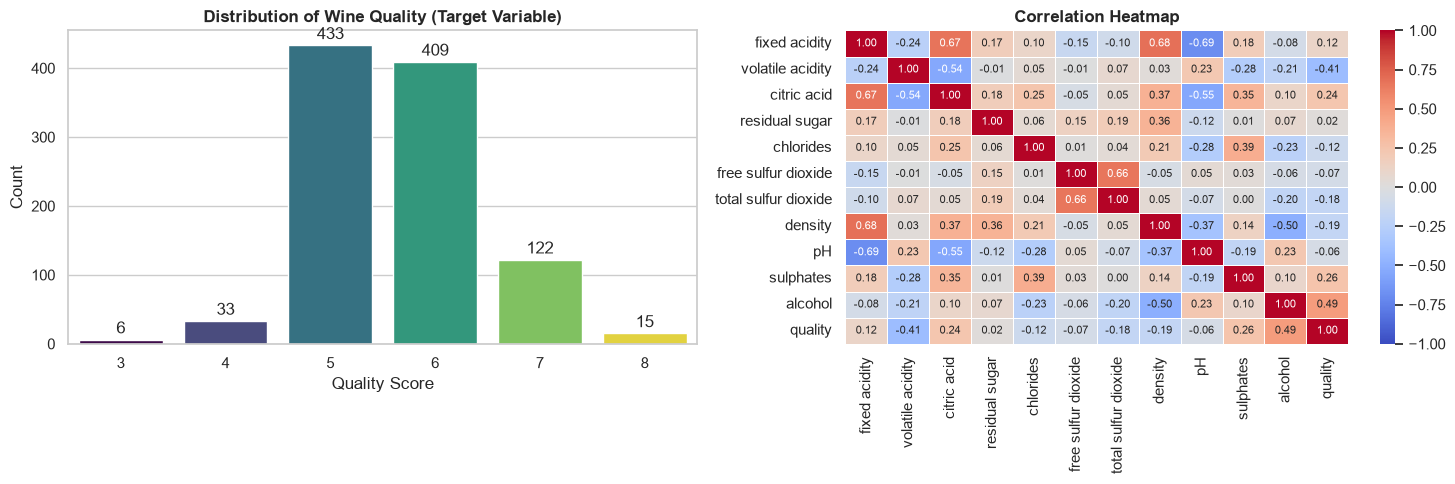

In [4]:
# ─── Part 1.3: Descriptive Statistics + Visualization ─────────────
# วัตถุประสงค์: ดูภาพรวมของข้อมูล การกระจายของ target และความสัมพันธ์ระหว่างตัวแปร

# 1. Summary statistics
print("=== สถิติเชิงพรรณนา (Descriptive Statistics) ===")
display(df.describe().T)

plt.figure(figsize=(15, 5))

# 2. Distribution ของ target ('quality')
plt.subplot(1, 2, 1)
ax = sns.countplot(x='quality', data=df, hue='quality', palette='viridis', legend=False)
plt.title('Distribution of Wine Quality (Target Variable)', fontweight='bold')
plt.xlabel('Quality Score')
plt.ylabel('Count')
for container in ax.containers:            # ใส่จำนวนบนแท่ง
    ax.bar_label(container, padding=2)

# 3. Correlation heatmap (Pearson)
plt.subplot(1, 2, 2)
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",
            linewidths=0.5, annot_kws={"size": 8}, vmin=-1, vmax=1)
plt.title('Correlation Heatmap', fontweight='bold')

plt.tight_layout()
plt.show()


In [5]:
# ─── Part 1.4: ตัวเลขสนับสนุน Insight ────────────────────────────
# วัตถุประสงค์: สรุปเป็นตัวเลข 3 เรื่อง — (1) ความไม่สมดุลของ target
#               (2) features ที่สัมพันธ์กับ quality (3) outliers

# (1) สัดส่วนของแต่ละระดับ quality
vc = df['quality'].value_counts().sort_index()
print("=== สัดส่วนของแต่ละระดับ quality ===")
print(pd.DataFrame({'count': vc, 'percent': (vc / len(df) * 100).round(2)}))
mid = vc.reindex([5, 6]).sum()
rare = vc.reindex([3, 4, 8]).sum()
print(f"\nquality 5 + 6 = {mid} แถว ({mid / len(df) * 100:.1f}%)")
print(f"quality 3 + 4 + 8 = {rare} แถว ({rare / len(df) * 100:.1f}%)")

# (2) correlation กับ quality: Pearson เทียบ Spearman (quality เป็น ordinal)
corr_q = pd.DataFrame({
    'Pearson': df.corr()['quality'],
    'Spearman': df.corr(method='spearman')['quality'],
}).drop('quality')
corr_q = corr_q.reindex(corr_q['Pearson'].abs().sort_values(ascending=False).index)
print("\n=== Correlation กับ quality (เรียงตาม |Pearson|) ===")
print(corr_q.round(3))

# (3) Outliers ด้วยกฎ IQR (1.5 × IQR)
feats = df.columns.drop('quality')
q1, q3 = df[feats].quantile(0.25), df[feats].quantile(0.75)
iqr = q3 - q1
n_out = ((df[feats] < q1 - 1.5 * iqr) | (df[feats] > q3 + 1.5 * iqr)).sum()
out_tbl = pd.DataFrame({'Q3': q3, 'max': df[feats].max(), 'จำนวน outlier (IQR)': n_out,
                        '% ของข้อมูล': (n_out / len(df) * 100).round(1)})
print("\n=== Outliers ตามกฎ IQR ===")
print(out_tbl.sort_values('จำนวน outlier (IQR)', ascending=False).round(4))


=== สัดส่วนของแต่ละระดับ quality ===
         count  percent
quality                
3            6     0.59
4           33     3.24
5          433    42.53
6          409    40.18
7          122    11.98
8           15     1.47

quality 5 + 6 = 842 แถว (82.7%)
quality 3 + 4 + 8 = 54 แถว (5.3%)

=== Correlation กับ quality (เรียงตาม |Pearson|) ===
                      Pearson  Spearman
alcohol                 0.486     0.495
volatile acidity       -0.409    -0.402
sulphates               0.258     0.393
citric acid             0.242     0.229
density                -0.185    -0.184
total sulfur dioxide   -0.182    -0.202
chlorides              -0.122    -0.210
fixed acidity           0.116     0.105
free sulfur dioxide    -0.071    -0.069
pH                     -0.058    -0.042
residual sugar          0.023     0.028

=== Outliers ตามกฎ IQR ===
                           Q3       max  จำนวน outlier (IQR)  % ของข้อมูล
residual sugar         2.6000   15.5000                   95        

**Insight จาก Part 1 (ข้อมูลหลังลบ duplicate: 1,018 แถว):**

> * **คุณภาพข้อมูล:** พบ observations จำนวน 125 แถวที่มีค่า chemical features และ quality เหมือนกันเมื่อไม่พิจารณา Id จึงตรวจสอบข้อมูลซ้ำในระดับ feature/target และ ใช้ข้อมูลที่ไม่ซ้ำกันสำหรับการวิเคราะห์ต่อไป เพื่อหลีกเลี่ยงการให้น้ำหนักกับชุดค่าที่เหมือนกันมากเกินไป
>
> * **Target (`quality`):** เป็นจำนวนเต็ม 3–8 (ไม่ใช่ 0–10) กระจุกที่ 5 (433 แถว) และ 6 (409 แถว) รวมกัน **82.7%** ส่วนระดับ 3, 4 และ 8 รวมกันเพียง 54 แถว (5.3%) การกระจายตัวของเป้าหมาย (target distribution) มีความไม่สมดุลอย่างมากในทั้ง 6 ระดับคุณภาพ โดยระดับคุณภาพที่ 5 และ 6 มีสัดส่วนรวมกันถึง 82.7% ของข้อมูลที่สังเกตได้ทั้งหมด

>
> * **ตัวแปรที่สัมพันธ์กับ quality:** `alcohol` มี Pearson correlation กับ quality สูงที่สุดในชุดข้อมูลนี้ และ `volatile acidity` (−0.41) สูงสุด ตามด้วย `sulphates` (+0.26), `citric acid` (+0.24), `density` (−0.19) และ `total sulfur dioxide` (−0.18) ส่วน `residual sugar` (0.02) และ `pH` (−0.06) แทบไม่สัมพันธ์ (Pearson เป็นค่าประมาณเพราะ quality เป็น ordinal จึงเทียบกับ Spearman ในตารางด้านบนด้วย)
>
> * **Multicollinearity:** `fixed acidity` สัมพันธ์สูงกับ `pH` (−0.69), `density` (+0.68) และ `citric acid` (+0.67) และ `free sulfur dioxide` กับ `total sulfur dioxide` (+0.66) ซึ่งเป็นเหตุผลที่ PCA ใน Part 2 จับกลุ่มตัวแปรได้ และต้องระวังเมื่อใช้ linear model
>
> * **Outliers:** `total sulfur dioxide` สูงสุด 289 (Q3 = 62), `chlorides` สูงสุด 0.611 (Q3 = 0.09), `residual sugar` สูงสุด 15.5 (Q3 = 2.6) และ `sulphates` สูงสุด 2.0 (Q3 = 0.72) observations ที่ถูก flag ด้วยกฎ IQR อาจมีอิทธิพลต่อ PCA และโมเดลที่ไวต่อ scale/distance เช่น KNN จึงควรตรวจสอบเพิ่มเติมว่าเป็นค่าผิดปกติจริงหรือเป็นค่าที่เกิดขึ้นได้ตามธรรมชาติของข้อมูล

---
## Part 2: CLO1 — Linear Algebra Analysis

ในส่วนนี้ให้ใช้ Linear Algebra เพื่อ analyze dataset

**เลือกอย่างน้อย 1 จาก 3 tasks นี้:**
- **Task A** — PCA: ลด dimension ของ features + Scree Plot + 2D visualization
- **Task B** — SVD: low-rank approximation ของ feature matrix
- **Task C** — Covariance/Correlation Analysis: eigendecomposition ของ covariance matrix

**คำอธิบาย:**

### Task A — Principal Component Analysis (PCA)

เลือกใช้ **Principal Component Analysis (PCA)** เพื่อวิเคราะห์โครงสร้างของข้อมูลคุณสมบัติทางเคมีของไวน์แดงและลดจำนวนมิติของ feature จาก 11 ตัวแปรให้อยู่ในมิติที่ต่ำลง โดย PCA จะค้นหาองค์ประกอบหลัก (Principal Components) ที่สามารถอธิบายความแปรปรวนของข้อมูลได้มากที่สุดผ่านแนวคิด Eigenvalues และ Eigenvectors ของ Covariance Matrix

การวิเคราะห์นี้ช่วยให้เห็นว่าตัวแปรทางเคมีใดมีส่วนร่วมต่อโครงสร้างข้อมูลมาก และสามารถนำข้อมูลมาแสดงในรูป 2 มิติเพื่อสำรวจรูปแบบการกระจายของข้อมูลและความแตกต่างของระดับคุณภาพไวน์ (`quality`)


=== PCA Input ===
Number of samples : 1018
Number of features: 11
Features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

=== PCA Summary ===


,Principal Component,Eigenvalue,Explained Variance (%),Cumulative Variance (%)
0,PC1,3.1645,28.7682,28.7682
1,PC2,1.8761,17.0551,45.8233
2,PC3,1.5764,14.3308,60.1541
3,PC4,1.2339,11.2172,71.3713
4,PC5,0.9623,8.7485,80.1198
5,PC6,0.6456,5.8692,85.9890
6,PC7,0.5575,5.0681,91.0571
7,PC8,0.4030,3.6634,94.7205
8,PC9,0.3467,3.1514,97.8720
9,PC10,0.1768,1.6069,99.4789



=== Verification ===
C = correlation matrix          : True
C v = λ v                       : True
Eigenvectors orthonormal (VᵀV=I): True
Σ eigenvalues = trace(C) = 11   : True
ตรงกับ sklearn (eigenvalue)      : True
ตรงกับ sklearn (eigenvector, ไม่คิดเครื่องหมาย): True


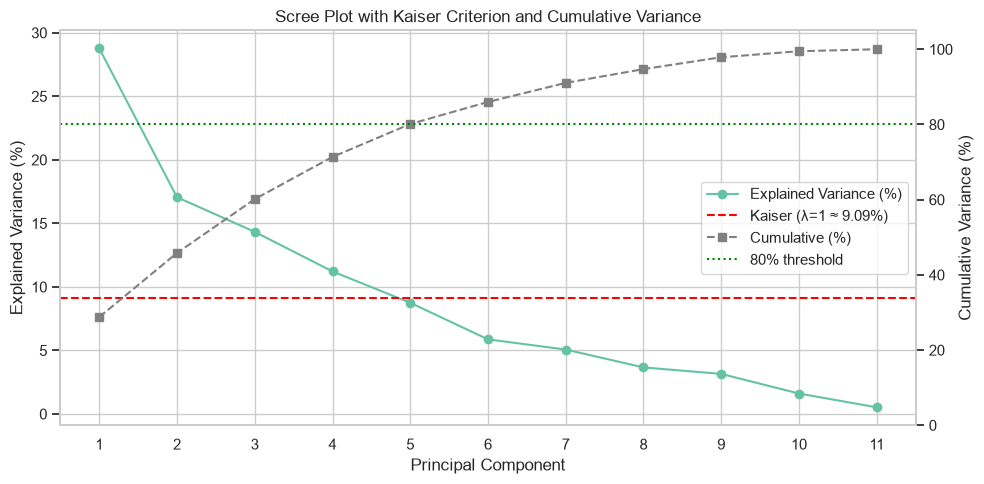


Original dimensions : 11
Reduced dimensions  : 2


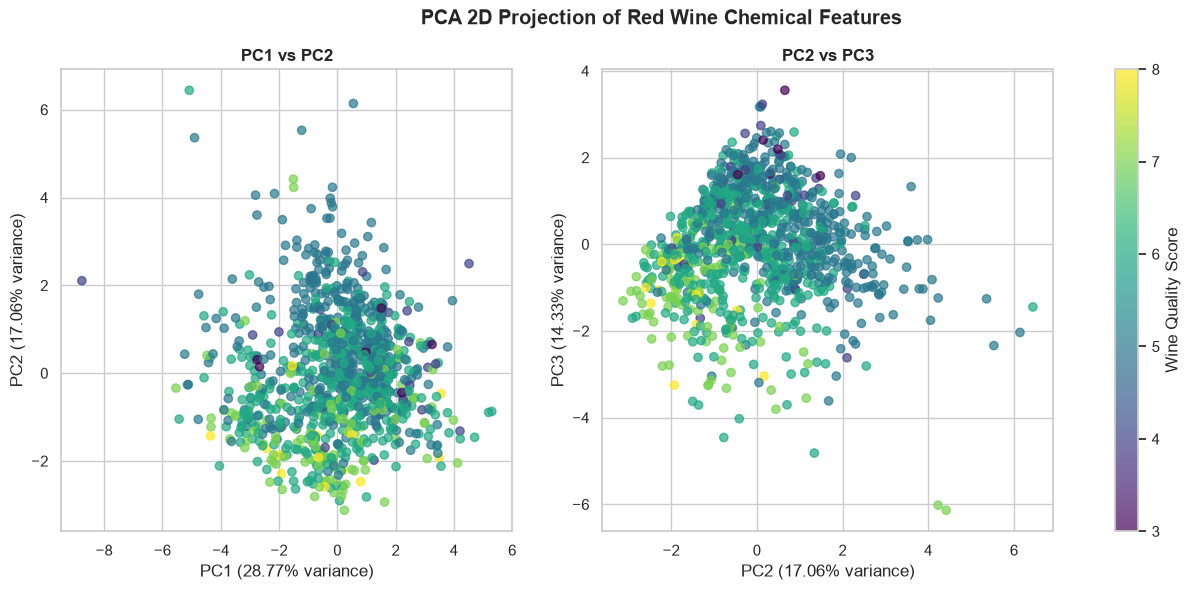

=== PCA Feature Loadings ===


,PC1,PC2,PC3,PC4
fixed acidity,-0.4823,-0.0952,0.1352,-0.2426
volatile acidity,0.2224,0.3063,0.4325,0.0758
citric acid,-0.4590,-0.1599,-0.2399,-0.0656
residual sugar,-0.1714,0.2225,-0.1009,-0.4125
chlorides,-0.2272,0.1362,0.0425,0.6510
free sulfur dioxide,0.0350,0.5019,-0.4540,-0.0327
total sulfur dioxide,-0.0253,0.5678,-0.3531,-0.0492
density,-0.3982,0.2253,0.3373,-0.1505
pH,0.4375,-0.0146,-0.0528,0.0099
sulphates,-0.2434,-0.1030,-0.2880,0.5234



=== Correlation ระหว่าง PC กับ quality ===
corr(PC1, quality) = -0.105   (r² = 1.1%)
corr(PC2, quality) = -0.432   (r² = 18.7%)
corr(PC3, quality) = -0.381   (r² = 14.5%)
corr(PC4, quality) = -0.076   (r² = 0.6%)

r² รวมของ PC1–PC4 (PC ตั้งฉากกัน จึงรวมกันได้) = 34.9%


In [6]:
# ─── CLO1: Linear Algebra Analysis (PCA) ─────────────────────────
# วัตถุประสงค์: ใช้ PCA ผ่าน Covariance Matrix, Eigenvalues และ Eigenvectors
# เพื่อวิเคราะห์โครงสร้างของคุณสมบัติทางเคมีของไวน์แดง

# 1. แยก Features และ Target (df ไม่มี Id แล้ว)
feature_cols = df.columns.drop('quality')
X = df[feature_cols].values
y = df['quality'].values

print("=== PCA Input ===")
print(f"Number of samples : {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print("Features:", feature_cols.tolist())

# 2. Standardization (ddof=1 ให้สอดคล้องกับ n-1 ในสูตร covariance)
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0, ddof=1)
X_scaled = (X - X_mean) / X_std

# 3. Covariance Matrix: C = (1/(n-1)) XᵀX  (เมื่อ standardize แล้ว C = correlation matrix)
n = X_scaled.shape[0]
C = (1 / (n - 1)) * (X_scaled.T @ X_scaled)

# 4. Eigendecomposition (eigh ใช้กับ matrix สมมาตร)
eigenvalues, eigenvectors = np.linalg.eigh(C)

# 5. เรียงจากมากไปน้อย
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# 6. Explained Variance
explained_variance_ratio = eigenvalues / eigenvalues.sum()
cumulative_variance = np.cumsum(explained_variance_ratio)

pca_summary = pd.DataFrame({
    'Principal Component': [f'PC{i}' for i in range(1, len(eigenvalues) + 1)],
    'Eigenvalue': eigenvalues,
    'Explained Variance (%)': explained_variance_ratio * 100,
    'Cumulative Variance (%)': cumulative_variance * 100
})
print("\n=== PCA Summary ===")
display(pca_summary.round(4))

# 7. Verification: ตรวจว่าการคำนวณด้วยมือถูกต้อง
pca_sk = PCA(n_components=len(eigenvalues)).fit(X_scaled)
print("\n=== Verification ===")
print("C = correlation matrix          :", np.allclose(C, np.corrcoef(X, rowvar=False)))
print("C v = λ v                       :", np.allclose(C @ eigenvectors, eigenvectors * eigenvalues))
print("Eigenvectors orthonormal (VᵀV=I):", np.allclose(eigenvectors.T @ eigenvectors, np.eye(len(eigenvalues))))
print("Σ eigenvalues = trace(C) = 11   :", np.isclose(eigenvalues.sum(), len(eigenvalues)))
print("ตรงกับ sklearn (eigenvalue)      :", np.allclose(eigenvalues, pca_sk.explained_variance_))
print("ตรงกับ sklearn (eigenvector, ไม่คิดเครื่องหมาย):",
      np.allclose(np.abs(eigenvectors), np.abs(pca_sk.components_.T)))

# 8. Scree Plot + Kaiser criterion + Cumulative variance
fig, ax1 = plt.subplots(figsize=(10, 5))
pcs = list(range(1, len(eigenvalues) + 1))

ax1.plot(pcs, explained_variance_ratio * 100, 'o-', label='Explained Variance (%)')
ax1.axhline(100 / len(eigenvalues), color='red', ls='--',
            label=f'Kaiser (λ=1 ≈ {100/len(eigenvalues):.2f}%)')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance (%)')
ax1.set_xticks(pcs)

ax2 = ax1.twinx()
ax2.plot(pcs, cumulative_variance * 100, 's--', color='gray', label='Cumulative (%)')
ax2.axhline(80, color='green', ls=':', label='80% threshold')
ax2.set_ylabel('Cumulative Variance (%)')
ax2.set_ylim(0, 105)
ax2.grid(False)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='center right')
ax1.set_title('Scree Plot with Kaiser Criterion and Cumulative Variance')
plt.tight_layout()
plt.show()

# 9. Projection: คะแนนของทุก PC (n × 11) และ 2 PC แรก (n × 2)
X_pca_all = X_scaled @ eigenvectors
X_pca = X_pca_all[:, :2]

print(f"\nOriginal dimensions : {X_scaled.shape[1]}")
print(f"Reduced dimensions  : {X_pca.shape[1]}")

# 10. PCA 2D Visualization: PC1 vs PC2 (แกนที่อธิบาย variance มากสุด)
#     และ PC2 vs PC3 (แกนที่สัมพันธ์กับ quality มากสุด)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (a, b) in zip(axes, [(0, 1), (1, 2)]):
    sc = ax.scatter(X_pca_all[:, a], X_pca_all[:, b], c=y, cmap='viridis', alpha=0.7)
    ax.set_xlabel(f"PC{a+1} ({explained_variance_ratio[a]*100:.2f}% variance)")
    ax.set_ylabel(f"PC{b+1} ({explained_variance_ratio[b]*100:.2f}% variance)")
    ax.set_title(f'PC{a+1} vs PC{b+1}', fontweight='bold')
fig.colorbar(sc, ax=axes, label='Wine Quality Score')
fig.suptitle('PCA 2D Projection of Red Wine Chemical Features', fontweight='bold')
plt.show()

# 11. Feature Loadings (PC1–PC4)
loadings = pd.DataFrame(eigenvectors[:, :4], index=feature_cols,
                        columns=['PC1', 'PC2', 'PC3', 'PC4'])
print("=== PCA Feature Loadings ===")
display(loadings.round(4))

# 12. Correlation ระหว่าง PC scores กับ quality
print("\n=== Correlation ระหว่าง PC กับ quality ===")
r_pc = []
for k in range(4):
    r = np.corrcoef(X_pca_all[:, k], y)[0, 1]
    r_pc.append(r)
    print(f"corr(PC{k+1}, quality) = {r:+.3f}   (r² = {r**2*100:.1f}%)")
print(f"\nr² รวมของ PC1–PC4 (PC ตั้งฉากกัน จึงรวมกันได้) = {sum(r**2 for r in r_pc)*100:.1f}%")


**Insight จาก CLO1 Analysis (ข้อมูลหลังลบ duplicate: 1,018 แถว, 11 features):**

> * **ความถูกต้องของการคำนวณ:** ผล eigendecomposition ที่เขียนเองตรงกับ `sklearn.decomposition.PCA` (eigenvalue และ eigenvector) โดย C เท่ากับ correlation matrix, Cv = λv, eigenvector ตั้งฉากกัน และผลรวม eigenvalue เท่ากับ trace(C) = 11
>
> * **Explained Variance:** PC1 มี Eigenvalue = 3.1645 อธิบายความแปรปรวนได้ 28.77% และ PC2 มี Eigenvalue = 1.8761 อธิบายได้ 17.06% รวมกัน **45.82%** การลดจาก 11 มิติเหลือ 2 มิติจึงเก็บความแปรปรวนไว้ได้ไม่ถึงครึ่ง ส่วนอีก 54.18% อยู่ใน PC อื่น
>
> * **PC1 (แกนความเป็นกรด):** loading สูงสุดคือ `fixed acidity` (−0.4823), `citric acid` (−0.4590), `pH` (+0.4375) และ `density` (−0.3982) กลุ่มกรดและ density เคลื่อนทิศทางเดียวกัน ส่วน pH สวนทาง สอดคล้องกับหลักเคมีที่ pH ลดลงเมื่อกรดเพิ่ม และสอดคล้องกับ correlation ที่สูงของกลุ่มนี้ใน heatmap
>
> * **PC2 (แกน sulfur dioxide):** PC2 มี Pearson correlation กับ quality เท่ากับ −0.432 และ PC3 เท่ากับ −0.381 ซึ่งสอดคล้องกับความสัมพันธ์เชิงเส้นระดับหนึ่ง แต่ความสัมพันธ์นี้เป็นการวิเคราะห์ภายหลังจาก PCA และไม่ได้เป็นเกณฑ์ที่ใช้เลือก Principal Components
>
> * **PC3 (แกนกรดระเหย–แอลกอฮอล์):** ค่าสูงหมายถึง `volatile acidity` (+0.4325) และ `density` (+0.3373) สูง พร้อมกับ `free sulfur dioxide` (−0.4540), `alcohol` (−0.4414), `total sulfur dioxide` (−0.3531) และ `sulphates` (−0.2880) ต่ำ
>
> * **PC4 (แกน chlorides–sulphates):** `chlorides` (+0.6510) และ `sulphates` (+0.5234) สูงพร้อมกัน ตรงข้ามกับ `residual sugar` (−0.4125)
>
> * **ความสัมพันธ์ระหว่าง PC กับ quality:** corr(PC1, quality) = −0.105, PC2 = **−0.432**, PC3 = **−0.381**, PC4 = −0.076 PC1 ซึ่งอธิบาย variance ของข้อมูลมากที่สุดแทบไม่เกี่ยวกับ quality (r² ≈ 1.1%) ส่วน PC2 และ PC3 อธิบายความแปรปรวนของ quality ได้ราว 18.7% และ 14.5% PC2 มี Pearson correlation กับ quality เท่ากับ -0.432และ PC3 มี Pearson correlation เท่ากับ -0.381โดย r² ของความสัมพันธ์เชิงเส้นกับ quality อยู่ที่ประมาณ 18.7% และ 14.5% ตามลำดับ การวิเคราะห์ความสัมพันธ์นี้เป็นการวิเคราะห์ ภายหลังจากสร้าง Principal Components และไม่ได้ถูกใช้เป็นเกณฑ์ในการสร้าง PCA เนื่องจาก PCA เป็น unsupervised จึงเลือกทิศทางตาม variance ของ X ไม่ใช่ตามความสามารถในการทำนาย target ทั้ง PC2 และ PC3 มีองค์ประกอบ "alcohol ต่ำ + volatile acidity สูง" ร่วมกัน สอดคล้องกับ correlation เชิงลบกับ quality ส่วน SO₂ ถูกแบ่งเป็นสองเครื่องหมายระหว่าง PC2 กับ PC3 จึงสรุปแบบตรงไปตรงมาไม่ได้ว่า SO₂ สูงแล้วคุณภาพต่ำ เมื่อรวม PC1–PC4 จะอธิบายความแปรปรวนของ quality ได้ราว 35% (บนข้อมูลชุดนี้)
>
> * **Scree Plot และการเลือกจำนวน PC:** เส้นลดลงต่อเนื่องโดยไม่มี elbow ชัดเจน (จุดหักเล็กน้อยที่ PC2 และ PC6) จึงใช้ Kaiser criterion ร่วมกับ cumulative variance: PC1–PC4 มี eigenvalue > 1 (PC4 = 1.2339, PC5 = 0.9623) อธิบายสะสม 71.37% และต้องใช้ PC1–PC5 จึงถึง 80.12% (PC1–PC6 = 85.99%)
>
> * **การแยกระดับคุณภาพบนกราฟ 2D:** บนกราฟ PC1–PC2 ไวน์คุณภาพสูง (7–8) กระจุกอยู่บริเวณ PC2 ต่ำ แต่กลุ่ม quality 5–6 ซ้อนทับกันมากและไม่เห็นแนวโน้มตามแกน PC1 เมื่อเปลี่ยนเป็นกราฟ **PC2 vs PC3** ซึ่งเป็นสองแกนที่สัมพันธ์กับ quality สูงสุด จะเห็น gradient แนวทแยงชัดเจน: ไวน์คุณภาพสูงอยู่มุมล่างซ้าย (SO₂ และ volatile acidity ต่ำ, alcohol สูง) ส่วนไวน์คุณภาพต่ำอยู่ด้านบนและขวา แสดงว่า PC ที่อธิบาย variance มากที่สุดไม่ใช่ PC ที่แยก target ได้ดีที่สุด แต่ยังมีการซ้อนทับในโซน quality 5–6 จึงเป็นข้อจำกัดของการแยกด้วย 2 แกนเชิงเส้น
>
> * **สรุป:** ข้อมูลเคมีของไวน์มีโครงสร้างหลายมิติ 2D PCA เหมาะกับการสำรวจและ visualization มากกว่าการใช้แทน 11 features ทั้งหมด นอกจากนี้ PCA ไวต่อ outlier เช่น `total sulfur dioxide` ที่สูงสุดถึง 289 และการลดมิติแบบ unsupervised ไม่ได้รับประกันว่า PC แรก ๆ จะเกี่ยวข้องกับ target


---
## Part 3: CLO2 — Statistical Learning

ในส่วนนี้ให้ทำ Statistical Analysis ที่เกี่ยวข้องกับ dataset

**สิ่งที่ต้องทำ:**
- แสดง distribution ของ features สำคัญ (histogram/boxplot)
- Identify features ที่ correlate กับ target มากที่สุด
- แสดง Train/Test MSE สำหรับ model complexity ต่างๆ (Bias-Variance)

**คำถาม:** dataset ของคุณเหมาะกับ Regression หรือ Classification? เพราะอะไร?

=== Top Features ที่สัมพันธ์กับ Quality ===
['alcohol', 'volatile acidity', 'sulphates', 'citric acid']


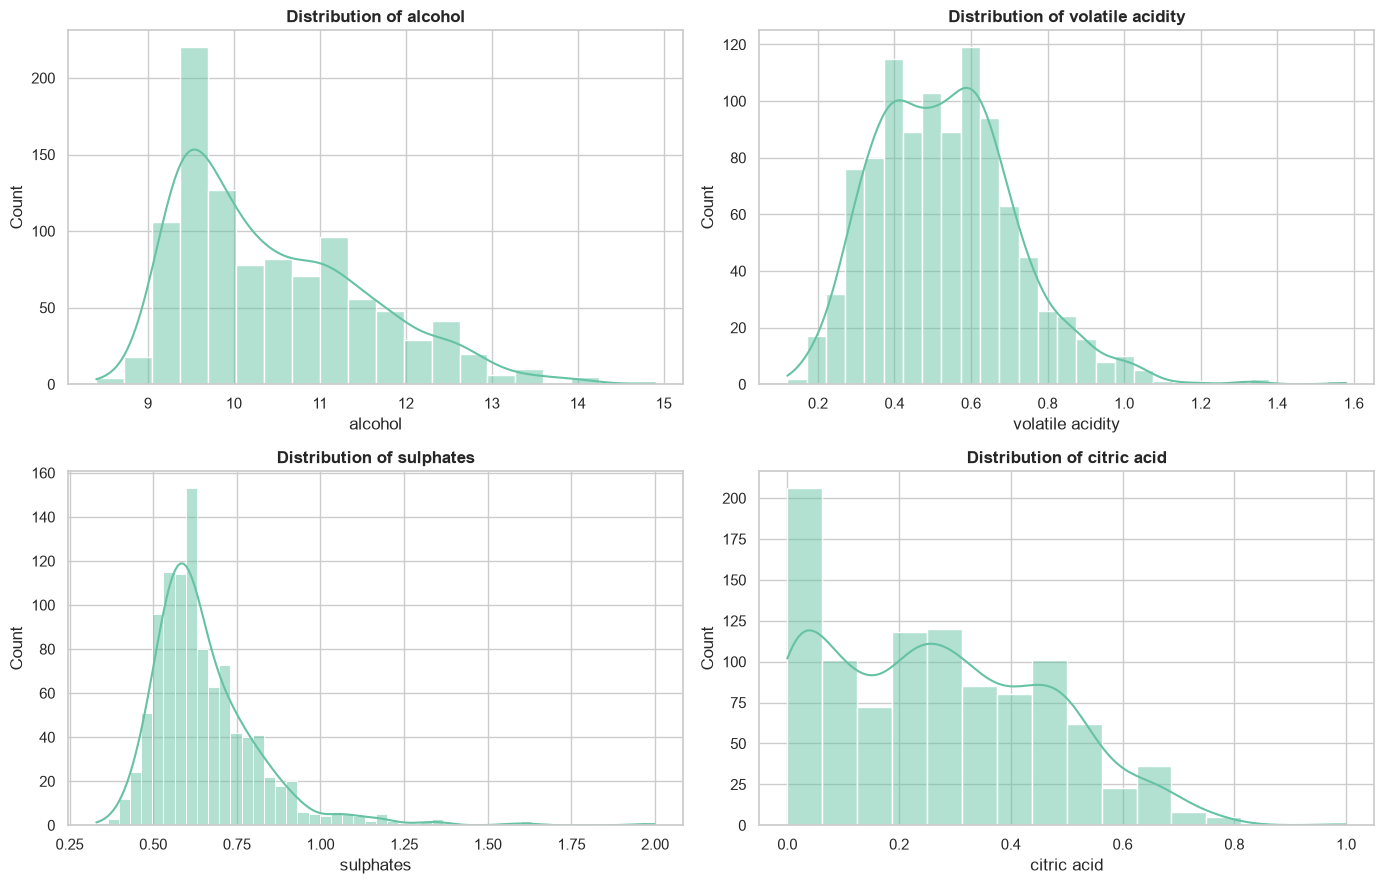

=== Correlation กับ Quality ===


,Pearson,Spearman,|Spearman|
alcohol,0.486,0.495,0.495
volatile acidity,-0.409,-0.402,0.402
sulphates,0.258,0.393,0.393
citric acid,0.242,0.229,0.229
chlorides,-0.122,-0.210,0.210
total sulfur dioxide,-0.182,-0.202,0.202
density,-0.185,-0.184,0.184
fixed acidity,0.116,0.105,0.105
free sulfur dioxide,-0.071,-0.069,0.069
pH,-0.058,-0.042,0.042


=== Train/Test MSE ตาม Model Complexity ===


,Polynomial Degree,Train MSE,Test MSE
0,1,0.4679,0.6440
1,2,0.4649,0.6435
2,3,0.4638,0.6355
3,4,0.4636,0.6350
4,5,0.4634,0.6345
5,6,0.4633,0.6341
6,7,0.4633,0.6336
7,8,0.4634,0.6330
8,9,0.4636,0.6322
9,10,0.4640,0.6313


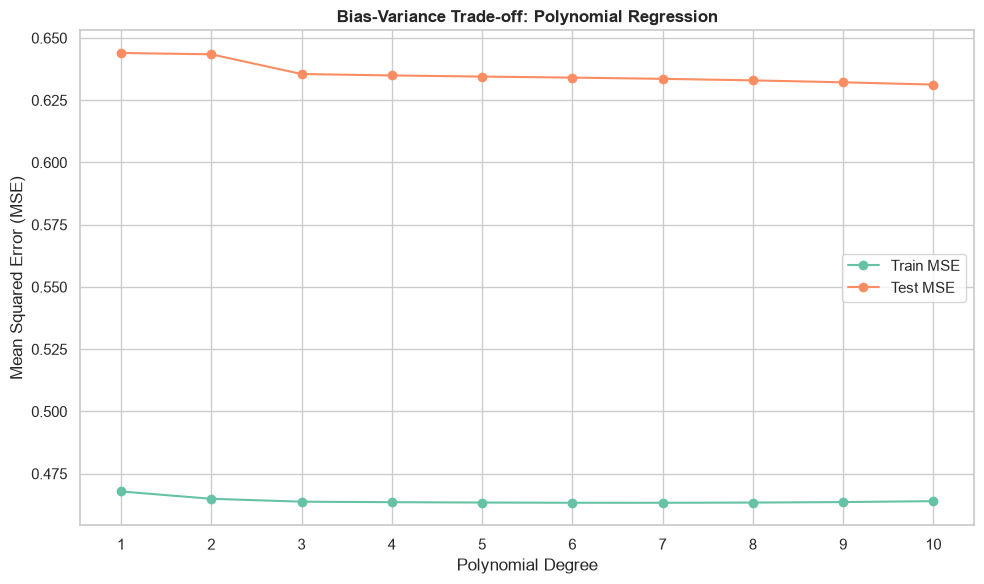

Best degree based on lowest Test MSE: 10
Train MSE = 0.4640
Test MSE  = 0.6313

=== Problem Framing ===
quality เป็นคะแนนแบบมีลำดับและมีค่าต่อเนื่องในระดับคะแนน 3–8 ดังนั้นในโปรเจกต์นี้สามารถกำหนดโจทย์เป็น Regression เพื่อทำนายค่า quality โดยตรงได้
Regression เหมาะกับกรณีที่เราต้องการวัดว่าค่าที่ทำนาย แตกต่างจากคะแนนจริงมากน้อยเพียงใดผ่าน MSE/RMSE


In [7]:
# ─── CLO2: Statistical Analysis ───────────────────────────────────
# วัตถุประสงค์:
# 1. วิเคราะห์ distribution ของ features ที่สัมพันธ์กับ quality
# 2. เปรียบเทียบ Pearson และ Spearman correlation กับ quality
# 3. ศึกษา Bias-Variance Trade-off ด้วย Train/Test MSE
#    จาก Polynomial Regression หลายระดับความซับซ้อน

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split


# ============================================================
# 1. Distribution ของ Features ที่สำคัญ
# ============================================================

# หา features ที่มีความสัมพันธ์กับ quality สูงที่สุด
corr_spearman = (
    df.corr(method='spearman')['quality']
    .drop('quality')
    .abs()
    .sort_values(ascending=False)
)

top_features = corr_spearman.head(4).index.tolist()

print("=== Top Features ที่สัมพันธ์กับ Quality ===")
print(top_features)

# Plot distribution ของ Top 4 Features
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(top_features):

    sns.histplot(
        data=df,
        x=col,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(
        f"Distribution of {col}",
        fontweight='bold'
    )

    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()


# ============================================================
# 2. Correlation Analysis กับ Target
# ============================================================

pearson_corr = (
    df.corr(method='pearson')['quality']
    .drop('quality')
)

spearman_corr = (
    df.corr(method='spearman')['quality']
    .drop('quality')
)

corr_summary = pd.DataFrame({
    'Pearson': pearson_corr,
    'Spearman': spearman_corr
})

corr_summary['|Spearman|'] = corr_summary['Spearman'].abs()

corr_summary = corr_summary.sort_values(
    '|Spearman|',
    ascending=False
)

print("=== Correlation กับ Quality ===")
display(corr_summary.round(3))


# ============================================================
# 3. Bias-Variance Trade-off
#    Polynomial Regression หลายระดับความซับซ้อน
# ============================================================

# ใช้ alcohol เป็นตัวอย่าง
# เพราะจาก Part 1 พบว่า alcohol มีความสัมพันธ์กับ quality สูงที่สุด

X = df[['alcohol']]
y = df['quality']

# แบ่ง Train / Test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

degrees = range(1, 11)

train_mse = []
test_mse = []

for degree in degrees:

    # สร้าง polynomial features
    poly = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Fit Linear Regression
    model = LinearRegression()

    model.fit(
        X_train_poly,
        y_train
    )

    # Prediction
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    # MSE
    train_mse.append(
        mean_squared_error(y_train, y_train_pred)
    )

    test_mse.append(
        mean_squared_error(y_test, y_test_pred)
    )


# สรุปผล MSE
mse_summary = pd.DataFrame({
    'Polynomial Degree': list(degrees),
    'Train MSE': train_mse,
    'Test MSE': test_mse
})

print("=== Train/Test MSE ตาม Model Complexity ===")
display(mse_summary.round(4))


# ============================================================
# 4. Plot Bias-Variance U-Curve
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    degrees,
    train_mse,
    marker='o',
    label='Train MSE'
)

plt.plot(
    degrees,
    test_mse,
    marker='o',
    label='Test MSE'
)

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error (MSE)")
plt.title(
    "Bias-Variance Trade-off: Polynomial Regression",
    fontweight='bold'
)

plt.xticks(list(degrees))
plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 5. หา Degree ที่ให้ Test MSE ต่ำที่สุด
# ============================================================

best_index = np.argmin(test_mse)
best_degree = list(degrees)[best_index]

print(
    f"Best degree based on lowest Test MSE: {best_degree}"
)

print(
    f"Train MSE = {train_mse[best_index]:.4f}"
)

print(
    f"Test MSE  = {test_mse[best_index]:.4f}"
)


# ============================================================
# 6. Problem Framing
# ============================================================

print("\n=== Problem Framing ===")
print(
    "quality เป็นคะแนนแบบมีลำดับและมีค่าต่อเนื่องในระดับคะแนน 3–8 "
    "ดังนั้นในโปรเจกต์นี้สามารถกำหนดโจทย์เป็น Regression "
    "เพื่อทำนายค่า quality โดยตรงได้"
)

print(
    "Regression เหมาะกับกรณีที่เราต้องการวัดว่าค่าที่ทำนาย "
    "แตกต่างจากคะแนนจริงมากน้อยเพียงใดผ่าน MSE/RMSE"
)

**Insight จาก CLO2 Analysis:**

> * **Features ที่สำคัญ:** จากการเปรียบเทียบ Pearson และ Spearman correlation พบว่า `alcohol` เป็นตัวแปรที่มีความสัมพันธ์กับ `quality` สูงที่สุด โดยมี Pearson correlation = **0.486** และ Spearman correlation = **0.495** รองลงมาคือ `volatile acidity` (Pearson = **−0.409**, Spearman = **−0.402**), `sulphates` (Pearson = **0.258**, Spearman = **0.393**) และ `citric acid` (Pearson = **0.242**, Spearman = **0.229**) ผลของ Pearson และ Spearman มีแนวโน้มสอดคล้องกัน โดยเฉพาะ `alcohol` และ `volatile acidity` ขณะที่ `sulphates` มี Spearman correlation สูงกว่า Pearson จึงควรพิจารณาความสัมพันธ์แบบ monotonic ร่วมด้วย เนื่องจาก `quality` เป็นคะแนนแบบ ordinal

> * **Distribution ของ Target:** ค่า `quality` อยู่ในช่วง **3–8** และมีการกระจายตัวไม่สมดุลระหว่างแต่ละระดับ โดย `quality = 5` มีจำนวน **433 แถว** และ `quality = 6` มี **409 แถว** รวมกันคิดเป็น **82.7%** ของข้อมูลหลังการลบ duplicate ขณะที่ระดับ 3, 4 และ 8 รวมกันมีเพียง **54 แถว (5.3%)** แสดงว่าข้อมูลส่วนใหญ่กระจุกอยู่ที่ quality ระดับ 5 และ 6

> * **Distribution ของ Features สำคัญ:** ได้เลือก `alcohol`, `volatile acidity`, `sulphates` และ `citric acid` ซึ่งเป็น 4 features ที่มีค่า absolute Spearman correlation กับ `quality` สูงที่สุดมาพิจารณาการกระจายของข้อมูล การดู histogram และ KDE ช่วยให้เห็นลักษณะการกระจาย ความเบ้ และช่วงค่าของตัวแปรก่อนนำไปสร้างโมเดล โดยเฉพาะตัวแปรที่มีความสัมพันธ์กับ target สูง ซึ่งอาจมีบทบาทต่อการทำนาย quality มากกว่าตัวแปรที่มีความสัมพันธ์ต่ำ

> * **Bias–Variance Trade-off:** จากการทดลอง Polynomial Regression โดยใช้ `alcohol` เป็นตัวแปรอิสระและเพิ่มระดับความซับซ้อนตั้งแต่ degree 1 ถึง 10 พบว่า Train MSE ลดลงจาก **0.4679** ที่ degree 1 เป็น **0.4640** ที่ degree 10 ขณะที่ Test MSE ลดลงจาก **0.6440** เป็น **0.6313** ดังนั้นในช่วง degree ที่ทดลอง **degree 10 ให้ Test MSE ต่ำที่สุด** อย่างไรก็ตาม Test MSE ลดลงเพียงเล็กน้อยและไม่มี U-curve ที่แสดงจุดเหมาะสมอย่างชัดเจน จึงไม่ควรสรุปว่า degree 10 เป็นความซับซ้อนที่เหมาะสมที่สุดสำหรับโมเดลสุดท้าย การเลือกโมเดลจริงควรตรวจสอบเพิ่มเติมด้วย Cross-Validation ใน CLO4

> * **Problem Framing:** เนื่องจาก `quality` เป็นคะแนนเชิงตัวเลขที่มีลำดับตั้งแต่ **3–8** และโครงงานต้องการทำนายค่าคะแนนโดยตรง จึงสามารถกำหนดปัญหาเป็น **Regression** ได้ โดยใช้ **MSE/RMSE** เป็นตัวชี้วัดความคลาดเคลื่อนระหว่างค่าที่ทำนายและค่าจริง ซึ่งสอดคล้องกับวัตถุประสงค์ของโครงงาน

> * **ข้อสรุปจาก CLO2:** `alcohol` และ `volatile acidity` เป็นตัวแปรที่มีความสัมพันธ์กับ `quality` เด่นที่สุด ข้อมูล target มีการกระจุกตัวสูงที่ quality = 5 และ 6 และการเพิ่ม polynomial complexity ในการทดลองนี้ช่วยลด Test MSE เพียงเล็กน้อย ดังนั้นความซับซ้อนที่เพิ่มขึ้นเพียงอย่างเดียวไม่ได้รับประกันประสิทธิภาพที่ดีขึ้น และควรใช้ Cross-Validation เพื่อเปรียบเทียบโมเดลอย่างเป็นระบบใน CLO4


---
## Part 4: CLO3 — Model Building

ในส่วนนี้ให้สร้าง Regression หรือ Classification model อย่างน้อย 2 models

**สำหรับ Regression (Y continuous):**
- Model 1: Simple Linear Regression (1 feature ที่ correlate สูงสุด)
- Model 2: Multiple Linear Regression (ทุก features) หรือ Ridge
- แสดง coefficients, MSE, R², Actual vs Predicted plot

**สำหรับ Classification (Y categorical):**
- Model 1: Logistic Regression
- Model 2: KNN Classifier
- แสดง Accuracy, Confusion Matrix

**Dataset ของกลุ่มเหมาะกับ:** ⬜ Regression  ⬜ Classification

In [ ]:
# ─── CLO3: Model 1 ─────────────────────────────────────────────────
# วัตถุประสงค์: [ระบุว่า Model 1 คืออะไร]

# TODO:
# X_train, X_test, y_train, y_test = train_test_split(...)
# model1 = ???
# model1.fit(X_train, y_train)
# ...
pass

In [ ]:
# ─── CLO3: Model 2 ─────────────────────────────────────────────────
# วัตถุประสงค์: [ระบุว่า Model 2 คืออะไร]

# TODO:
# model2 = ???
# ...
pass

**สรุป Model Comparison:**

| Model | Train Metric | Test Metric | รายละเอียด |
|-------|-------------|------------|----------|
| Model 1: ___ | | | |
| Model 2: ___ | | | |

**Insight:**
> [เปรียบเทียบ: Model ไหนดีกว่า? ทำไม? มี overfitting/underfitting ไหม?]

---
## Part 5: CLO4 — Model Selection

ในส่วนนี้ให้ใช้ Cross-Validation เพื่อเลือก model ที่ดีที่สุดอย่างเป็นธรรม

**สิ่งที่ต้องทำ:**
- เปรียบเทียบอย่างน้อย 3 models ด้วย 5-Fold Cross-Validation
- Plot bar chart ของ CV MSE (หรือ Accuracy สำหรับ Classification)
- สรุปว่า model ไหนดีที่สุดและทำไม

In [ ]:
# ─── CLO4: 5-Fold Cross-Validation ────────────────────────────────
# วัตถุประสงค์: เปรียบเทียบ models อย่างเป็นธรรมด้วย CV

# TODO:
# models = {
#     'Model 1': ???,
#     'Model 2': ???,
#     'Model 3': ???,
# }
#
# for name, model in models.items():
#     scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
#     cv_mse = -scores.mean()
#     print(f'{name}: CV MSE = {cv_mse:.4f}')
pass

**Best Model จาก Cross-Validation:** [ระบุ]

**เหตุผล:**
> [อธิบาย: CV MSE ต่ำสุดคือเท่าไหร่? มี overfitting ไหม? เชื่อมกับ Bias-Variance อย่างไร?]

---
## Part 6: สรุปผลและ Data Story

**6.1 สรุปผลการวิเคราะห์:**
> [สรุป findings หลักจากแต่ละ CLO ใน 4-5 bullet points]
- CLO1: ...
- CLO2: ...
- CLO3: ...
- CLO4: ...

**6.2 Limitations:**
> [อะไรที่ทำไม่ได้หรือมีข้อจำกัด เช่น dataset เล็กเกินไป, missing values, features ไม่ครบ]

**6.3 ขั้นตอนต่อไป (Future Work):**
> [ถ้ามีเวลามากกว่านี้จะทำอะไรต่อ]

**6.4 Connection กับ Topics ในวิชา:**
> [เชื่อมกับ Week ต่างๆ ที่เรียนมา ว่า concept ไหนนำมาใช้จริงในโครงงานนี้]

---
**Acknowledgements:** [ขอบคุณแหล่งข้อมูล / tools / references ที่ใช้]